In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    TimeSeriesSplit,
    GridSearchCV
)

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

from statsmodels.tsa.statespace.sarimax import SARIMAX

In [45]:
# Load Dataset
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [46]:
# Dataset Overview
print("Shape :",df.shape)

df.info()

df.describe()

df.isnull().sum()

Shape : (2640, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


In [48]:
# Data Preprocessing
df.drop_duplicates(inplace=True)

In [49]:
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01')
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01


In [50]:
df = df.sort_values('Date')

df.reset_index(drop=True,inplace=True)

In [51]:
print(df.isnull().sum())

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
Date                    0
dtype: int64


In [77]:
# Feature Engineering
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter

In [78]:
df['Month_Sin'] = np.sin(
    2*np.pi*df['Month']/12
)

df['Month_Cos'] = np.cos(
    2*np.pi*df['Month']/12
)

In [79]:
df['Lag1'] = df['Estimated_Deliveries'].shift(1)

df['Lag2'] = df['Estimated_Deliveries'].shift(2)

In [80]:
df['RollingMean3'] = (
    df['Estimated_Deliveries']
    .rolling(3)
    .mean()
)

In [13]:
df.dropna(inplace=True)

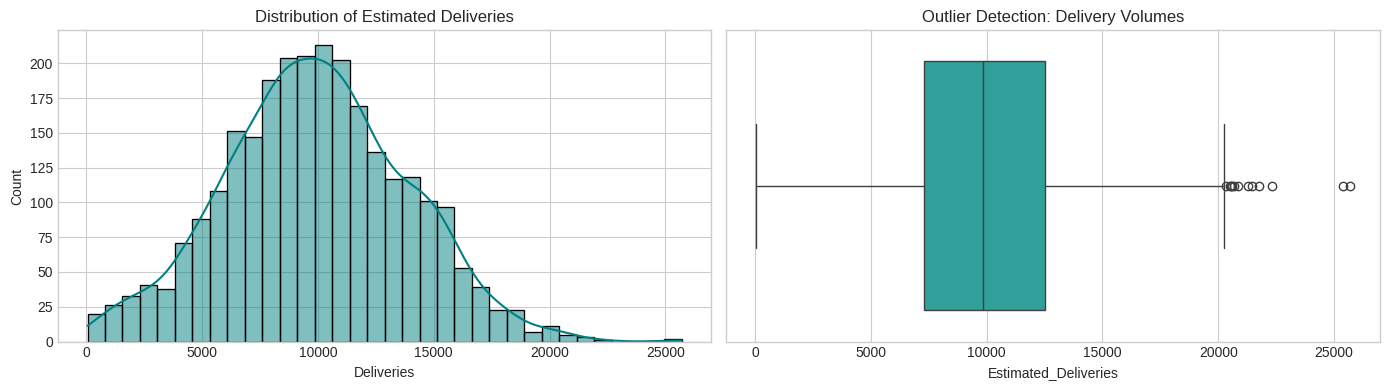

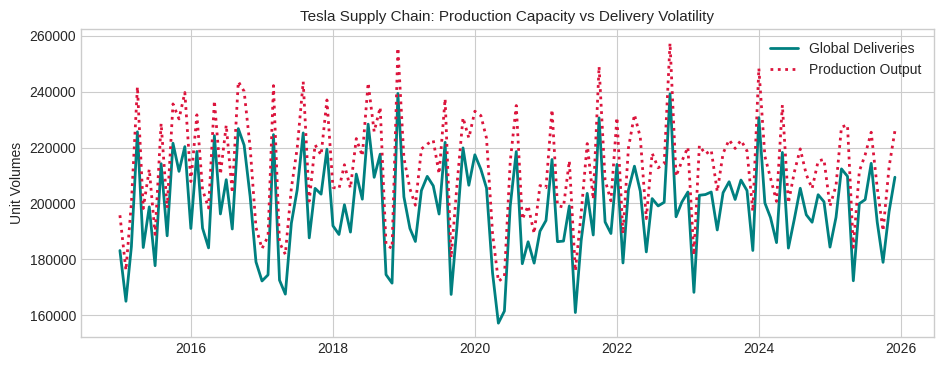

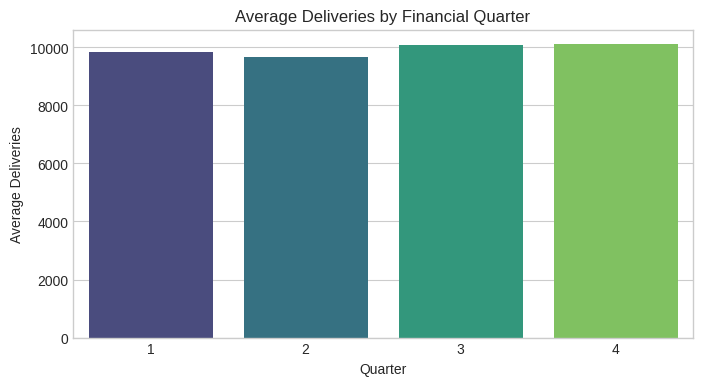

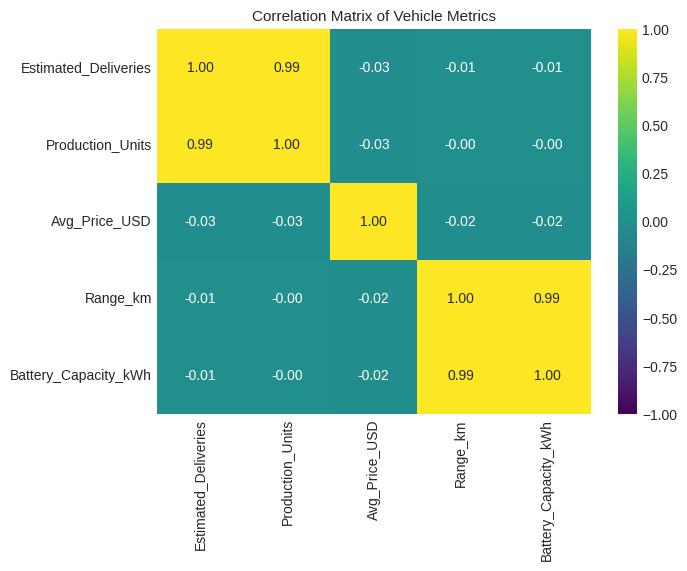

In [81]:
# Establish a uniform grid style for clear visual interpretation
plt.style.use('seaborn-v0_8-whitegrid')

# Re-create Quarter column to ensure it exists for plotting
df['Quarter'] = df['Date'].dt.quarter

# 1. Target Variable Distribution & Outlier Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df['Estimated_Deliveries'], kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Estimated Deliveries')
axes[0].set_xlabel('Deliveries')

sns.boxplot(x=df['Estimated_Deliveries'], ax=axes[1], color='lightseagreen')
axes[1].set_title('Outlier Detection: Delivery Volumes')
plt.tight_layout()
plt.show()

# 2. Check macro trend: Demand (deliveries) vs Supply capacity (production)
plt.figure(figsize=(11, 4))
monthly_aggregates = df.groupby('Date')[['Estimated_Deliveries', 'Production_Units']].sum()
plt.plot(monthly_aggregates.index, monthly_aggregates['Estimated_Deliveries'], label='Global Deliveries', color='teal', linewidth=2)
plt.plot(monthly_aggregates.index, monthly_aggregates['Production_Units'], label='Production Output', color='crimson', linestyle=':', linewidth=2)
plt.title('Tesla Supply Chain: Production Capacity vs Delivery Volatility', fontsize=11)
plt.ylabel('Unit Volumes')
plt.legend()
plt.show()

# 3. Delivery Trends by Quarter (Seasonality Check)
plt.figure(figsize=(8, 4))
sns.barplot(data=df, x='Quarter', y='Estimated_Deliveries', errorbar=None, palette='viridis')
plt.title('Average Deliveries by Financial Quarter')
plt.ylabel('Average Deliveries')
plt.show()

# 4. Multicollinearity check
plt.figure(figsize=(7, 5))
target_features = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Range_km', 'Battery_Capacity_kWh']
sns.heatmap(df[target_features].corr(), annot=True, cmap='viridis', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Matrix of Vehicle Metrics', fontsize=11)
plt.show()

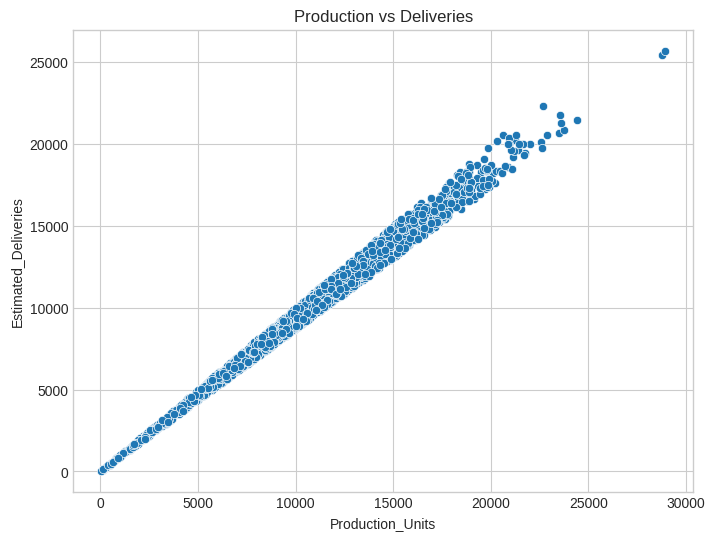

In [82]:
# Exploratory Data Analysis (EDA)
# Production Units vs Deliveries
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Production_Units',
    y='Estimated_Deliveries'
)

plt.title("Production vs Deliveries")

plt.show()

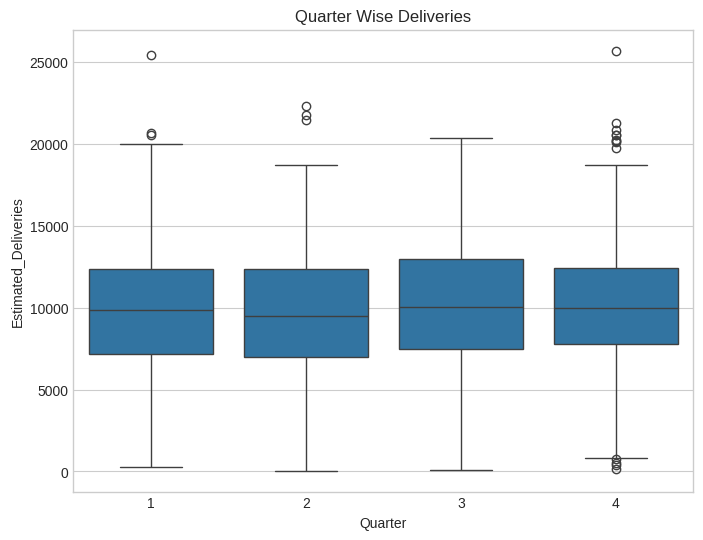

In [83]:
# Deliveries by Quarter
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='Quarter',
    y='Estimated_Deliveries'
)

plt.title("Quarter Wise Deliveries")

plt.show()

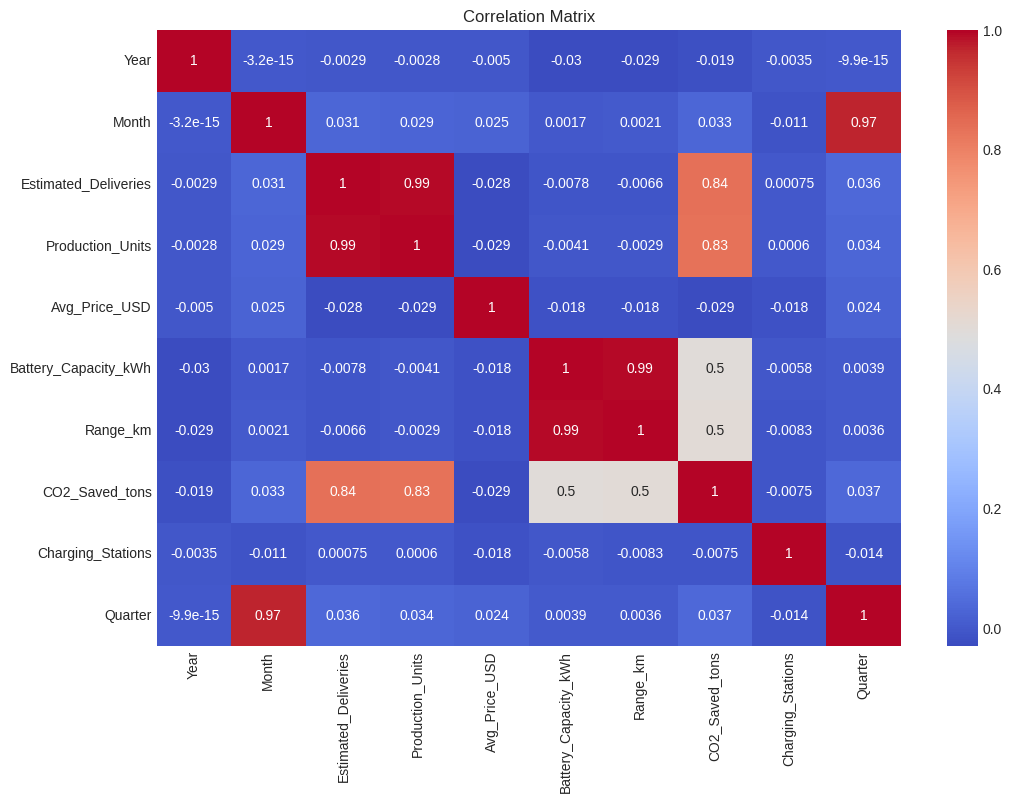

In [59]:
# Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

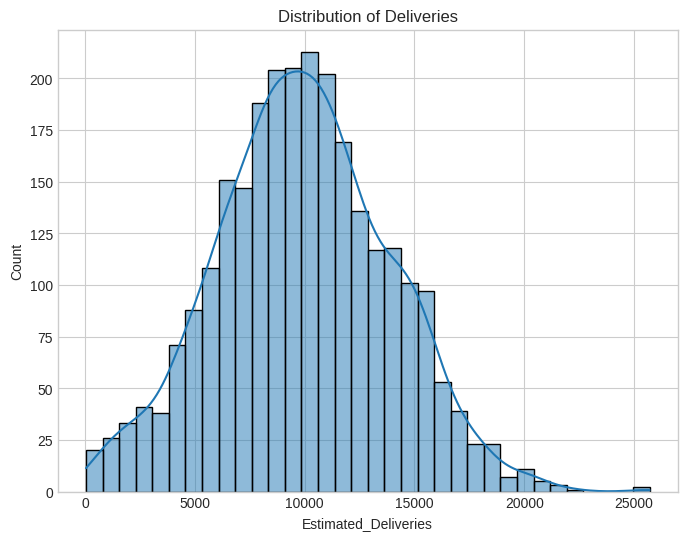

In [60]:
# Distribution of Deliveries
plt.figure(figsize=(8,6))

sns.histplot(
    df['Estimated_Deliveries'],
    kde=True
)

plt.title("Distribution of Deliveries")

plt.show()

In [61]:
# Define Features and Target
X = df.drop(
    columns=[
        'Date',
        'Estimated_Deliveries'
    ]
)

y = df['Estimated_Deliveries']

In [62]:
# TimeSeriesSplit Validation
tscv = TimeSeriesSplit(
    n_splits=5
)

for train_index,test_index in tscv.split(X):

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

In [63]:
# Linear Regression Model
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()


X_train_encoded = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)


X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='outer', axis=1, fill_value=0)

lr = LinearRegression()

lr.fit(
    X_train_encoded,
    y_train
)

pred_lr = lr.predict(X_test_encoded)

In [65]:
# Random Forest Regression
rf = RandomForestRegressor(
    random_state=42
)

rf.fit(
    X_train_encoded, # Use the encoded X_train
    y_train
)

pred_rf = rf.predict(X_test_encoded) # Use the encoded X_test

In [66]:
# XGBoost Regression
xgb = XGBRegressor(
    random_state=42
)

xgb.fit(
    X_train_encoded, # Use the encoded X_train
    y_train
)

pred_xgb = xgb.predict(X_test_encoded) # Use the encoded X_test

In [67]:
# Hyperparameter Tuning (XGBoost)
param_grid = {

    'n_estimators':[100,200,300],

    'max_depth':[3,5,7],

    'learning_rate':[0.01,0.05,0.1]
}

grid = GridSearchCV(

    XGBRegressor(),

    param_grid,

    cv=3,

    scoring='r2',

    n_jobs=-1
)

grid.fit(
    X_train_encoded,
    y_train
)

best_model = grid.best_estimator_

print(grid.best_params_)

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}


In [69]:
# Evaluation Metrics
def evaluate_model(
    y_true,
    y_pred,
    model_name
):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    mape = mean_absolute_percentage_error(
        y_true,
        y_pred
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    print("\n",model_name)

    print("MAE :",mae)

    print("RMSE :",rmse)

    print("MAPE :",mape)

    print("R2 :",r2)

In [70]:
# Evaluate All Models
evaluate_model(
    y_test,
    pred_lr,
    "Linear Regression"
)

evaluate_model(
    y_test,
    pred_rf,
    "Random Forest"
)

evaluate_model(
    y_test,
    pred_xgb,
    "XGBoost"
)


 Linear Regression
MAE : 319.7069197708482
RMSE : 390.9338393774235
MAPE : 0.03832531991209248
R2 : 0.9886514320573906

 Random Forest
MAE : 307.75652272727274
RMSE : 384.83750005477515
MAPE : 0.031983465309231324
R2 : 0.9890026182196743

 XGBoost
MAE : 224.39964294433594
RMSE : 290.2601069515065
MAPE : 0.02556782029569149
R2 : 0.9937438368797302


In [71]:
# Model Comparison Table
results = pd.DataFrame({

    'Model':[
        'Linear Regression',
        'Random Forest',
        'XGBoost'
    ],

    'R2':[
        r2_score(y_test,pred_lr),
        r2_score(y_test,pred_rf),
        r2_score(y_test,pred_xgb)
    ],

    'RMSE':[

        np.sqrt(mean_squared_error(y_test,pred_lr)),

        np.sqrt(mean_squared_error(y_test,pred_rf)),

        np.sqrt(mean_squared_error(y_test,pred_xgb))
    ]
})

results.sort_values(
    by='R2',
    ascending=False
)

,Model,R2,RMSE
2,XGBoost,0.993744,290.260107
1,Random Forest,0.989003,384.837500
0,Linear Regression,0.988651,390.933839


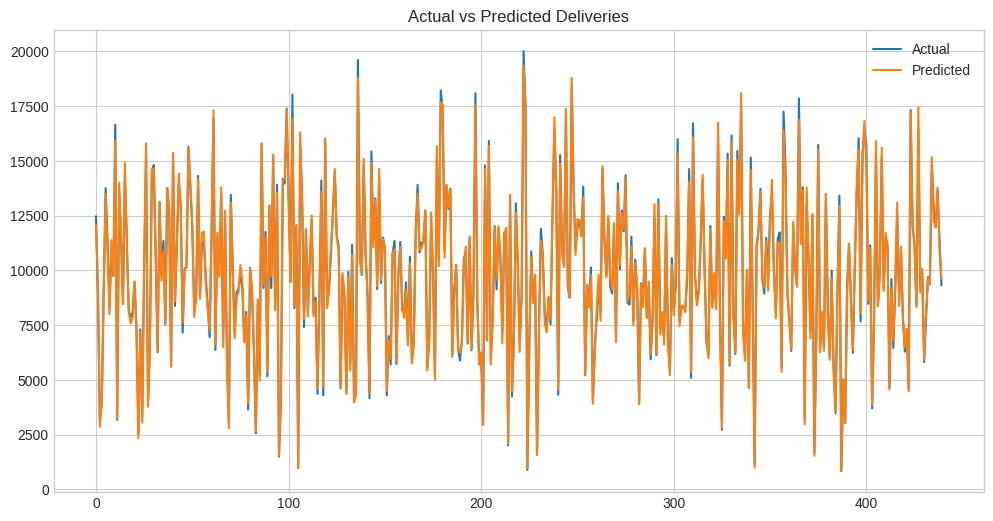

In [72]:
# Actual vs Predicted Graph
best_pred = best_model.predict(X_test_encoded)

plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label='Actual'
)

plt.plot(
    best_pred,
    label='Predicted'
)

plt.title(
    "Actual vs Predicted Deliveries"
)

plt.legend()

plt.show()

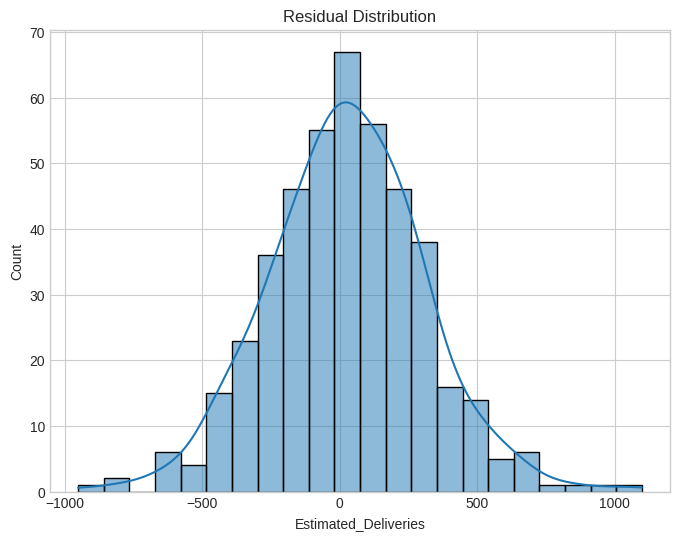

In [73]:
# Residual Analysis
residuals = y_test - best_pred

plt.figure(figsize=(8,6))

sns.histplot(
    residuals,
    kde=True
)

plt.title(
    "Residual Distribution"
)

plt.show()

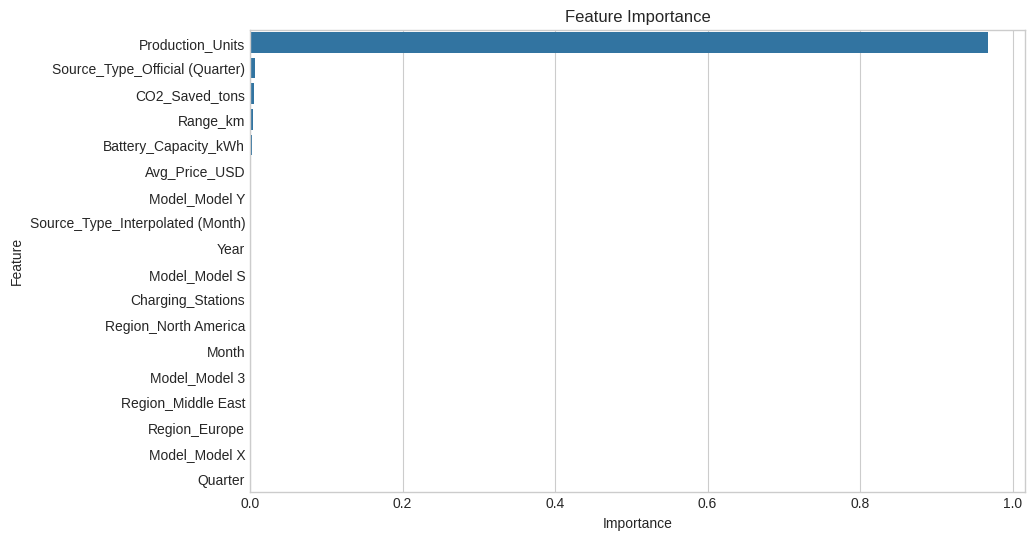

In [74]:
# Feature Importance
importance = pd.DataFrame({

    'Feature':X_train_encoded.columns,

    'Importance':
    best_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(

    x='Importance',

    y='Feature',

    data=importance
)

plt.title(
    "Feature Importance"
)

plt.show()

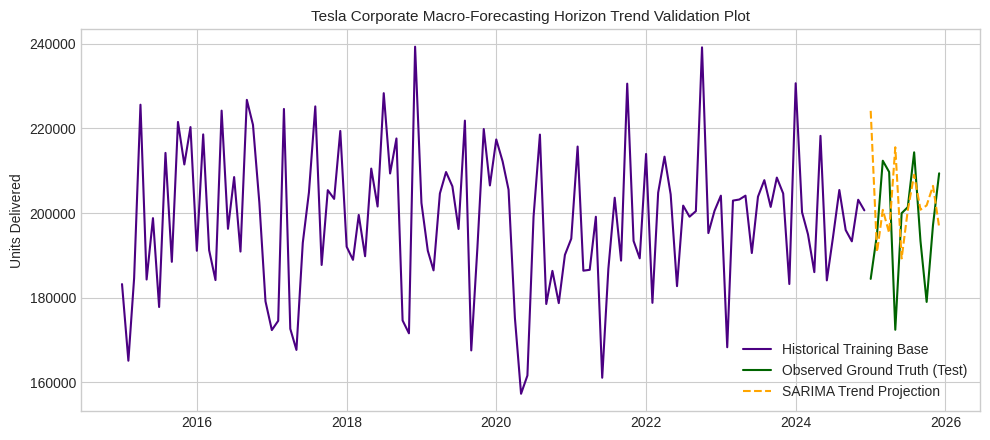

--- SARIMA 12-Month Forecast Metrics ---
Validation MAE:  15186.70 units
Validation RMSE: 19943.76 units


In [76]:
# Seasonal Time Series Forecasting (SARIMA)
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Compress multiple records into a single consolidated, monthly global delivery stream
time_series_stream = df.groupby('Date')['Estimated_Deliveries'].sum().asfreq('MS')

# Hold out the final 12 months as a historical validation test window
history_train = time_series_stream.iloc[:-12]
future_validation = time_series_stream.iloc[-12:]

# Set a 12-month seasonal period to explicitly map annual recurring auto industry cycles
forecasting_engine = SARIMAX(history_train, order=(1, 1, 1), seasonal_order=(1, 1, 0, 12))
trained_forecaster = forecasting_engine.fit(disp=False)

# Forecast deliveries exactly 12 months out into the validation window
horizon_predictions = trained_forecaster.get_forecast(steps=12).predicted_mean

# Plot the training history, ground truth test data, and model forecast for validation
plt.figure(figsize=(10, 4.5))
plt.plot(history_train.index, history_train, label='Historical Training Base', color='indigo')
plt.plot(future_validation.index, future_validation, label='Observed Ground Truth (Test)', color='darkgreen')
plt.plot(horizon_predictions.index, horizon_predictions, label='SARIMA Trend Projection', color='orange', linestyle='--')
plt.title('Tesla Corporate Macro-Forecasting Horizon Trend Validation Plot', fontsize=11)
plt.ylabel('Units Delivered')
plt.legend()
plt.tight_layout()
plt.show()

# Calculate quantitative metrics for the SARIMA 12-month forecast
sarima_mae = mean_absolute_error(future_validation, horizon_predictions)
sarima_rmse = np.sqrt(mean_squared_error(future_validation, horizon_predictions))

print("--- SARIMA 12-Month Forecast Metrics ---")
print(f"Validation MAE:  {sarima_mae:.2f} units")
print(f"Validation RMSE: {sarima_rmse:.2f} units")
